In [ ]:
import numpy as np
import pandas as pd

In [ ]:
books=pd.read_csv("books.csv")
ratings=pd.read_csv("ratings.csv")
tags=pd.read_csv("tags.csv")

In [ ]:
print(books.shape)
books.head()

(10000, 23)


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [ ]:

ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [ ]:
tags.head()

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


In [ ]:
print(books.shape)
print(ratings.shape)
print(tags.shape)

(10000, 23)
(981756, 3)
(34252, 2)


In [ ]:
books.isnull().sum()

id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url                 0
dtype: int64

In [ ]:
ratings.isnull().sum()

book_id    0
user_id    0
rating     0
dtype: int64

In [ ]:
tags.isnull().sum()

tag_id      0
tag_name    0
dtype: int64

In [ ]:
books.duplicated().sum()

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

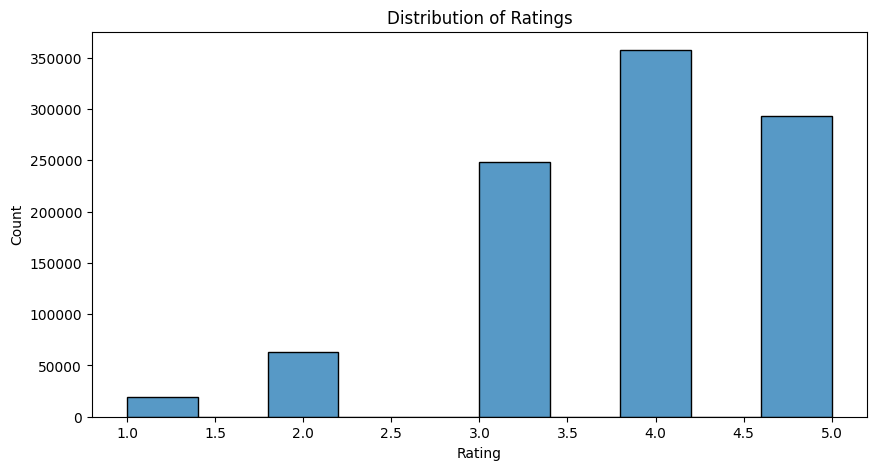

In [ ]:
plt.figure(figsize=(10,5))   # Plot ka size set karte hain
sns.histplot(ratings['rating'], bins=10, kde=False)  # Histogram
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
top_books = ratings['book_id'].value_counts().head(10)  # 10 most rated books
top_books

book_id
9981    100
9977    100
9976    100
32      100
31      100
30      100
29      100
28      100
27      100
26      100
Name: count, dtype: int64

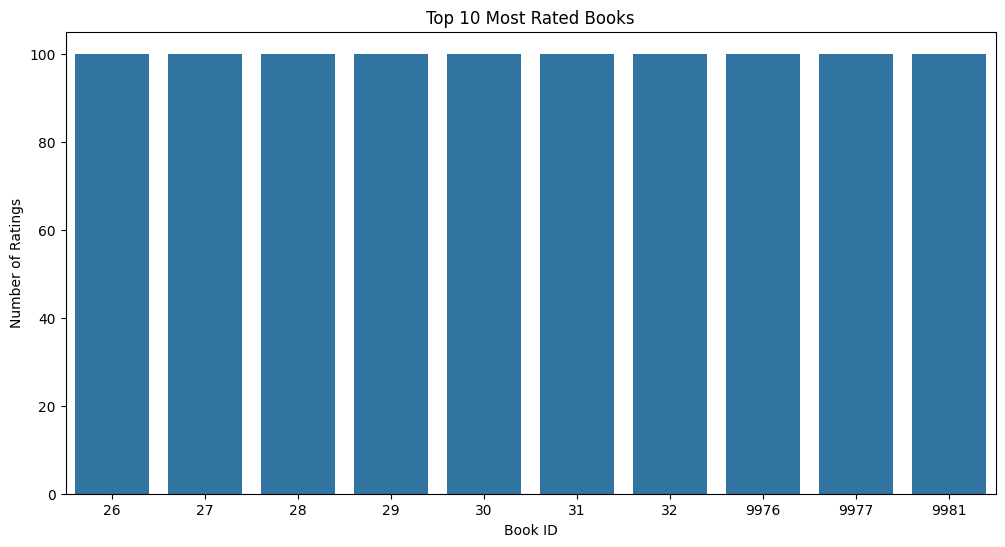

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_books.index, y=top_books.values)
plt.title("Top 10 Most Rated Books")
plt.xlabel("Book ID")
plt.ylabel("Number of Ratings")
plt.show()

In [ ]:
book_avg_rating = ratings.groupby('book_id')['rating'].mean().sort_values(ascending=True).head(10)
book_avg_rating

book_id
1793    1.960000
4045    2.235294
7636    2.312500
1822    2.350515
1409    2.430000
4399    2.457447
4991    2.462687
3550    2.490000
4009    2.530000
4283    2.540000
Name: rating, dtype: float64

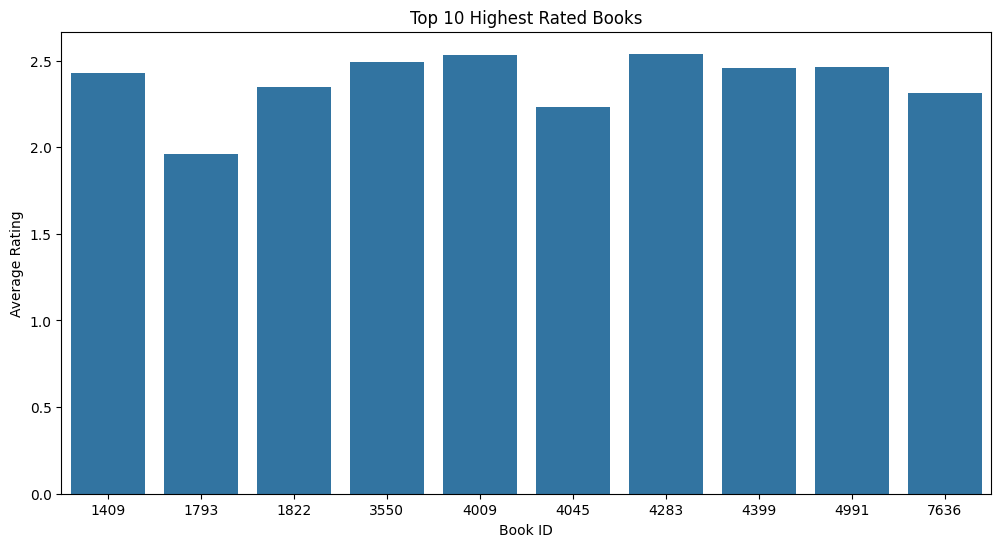

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=book_avg_rating.index, y=book_avg_rating.values)
plt.title("Top 10 Highest Rated Books")
plt.xlabel("Book ID")
plt.ylabel("Average Rating")
plt.show()


In [ ]:
ratings.duplicated().sum()

np.int64(1644)

In [ ]:
ratings = ratings.drop_duplicates(subset=['user_id','book_id'], keep='last')

In [ ]:
merged = ratings.merge(books[['book_id','title','authors']], on='book_id', how='left')

In [ ]:
merged

,book_id,user_id,rating,title,authors
0,1,314,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
1,1,439,3,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
2,1,588,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
3,1,1169,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
4,1,1185,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
...,...,...,...,...,...
979473,10000,48386,5,NaN,NaN
979474,10000,49007,4,NaN,NaN
979475,10000,49383,5,NaN,NaN
979476,10000,50124,5,NaN,NaN


In [ ]:
merged.isnull().sum()

book_id         0
user_id         0
rating          0
title      899947
authors    899947
dtype: int64

In [ ]:
merged = merged.dropna(subset=['user_id','book_id','rating','title','authors'])

In [ ]:
merged.isnull().sum()

book_id    0
user_id    0
rating     0
title      0
authors    0
dtype: int64

In [ ]:
num_rating_df=merged.groupby('title').count()['rating'].reset_index()
num_rating_df.rename(columns={'rating':'num_ratings'},inplace=True)
num_rating_df

,title,num_ratings
0,'Salem's Lot,74
1,"'Tis (Frank McCourt, #2)",99
2,1421: The Year China Discovered America,98
3,1776,100
4,1984,100
...,...,...
807,Year of Wonders,100
808,You Shall Know Our Velocity!,100
809,Zen and the Art of Motorcycle Maintenance: An ...,100
810,Zodiac,99


In [ ]:
avg_rating_df = merged.groupby('title')['rating'].mean().reset_index()
avg_rating_df.rename(columns={'rating':'avg_ratings'}, inplace=True)
avg_rating_df

,title,avg_ratings
0,'Salem's Lot,3.932432
1,"'Tis (Frank McCourt, #2)",3.959596
2,1421: The Year China Discovered America,3.734694
3,1776,3.930000
4,1984,3.170000
...,...,...
807,Year of Wonders,3.760000
808,You Shall Know Our Velocity!,3.490000
809,Zen and the Art of Motorcycle Maintenance: An ...,3.550000
810,Zodiac,3.646465


In [ ]:
popular_df=num_rating_df.merge(avg_rating_df,on='title')
popular_df

,title,num_ratings,avg_ratings
0,'Salem's Lot,74,3.932432
1,"'Tis (Frank McCourt, #2)",99,3.959596
2,1421: The Year China Discovered America,98,3.734694
3,1776,100,3.930000
4,1984,100,3.170000
...,...,...,...
807,Year of Wonders,100,3.760000
808,You Shall Know Our Velocity!,100,3.490000
809,Zen and the Art of Motorcycle Maintenance: An ...,100,3.550000
810,Zodiac,99,3.646465


In [ ]:
popular_df[popular_df['num_ratings']>=100].sort_values('avg_ratings',ascending=False).head(50)

,title,num_ratings,avg_ratings
515,The Beautiful and Damned,100,4.66
706,The Taste of Home Cookbook,100,4.55
29,A People's History of the United States,100,4.54
219,Girl with a Pearl Earring,100,4.53
145,Deception Point,100,4.50
554,The Curious Incident of the Dog in the Night-Time,100,4.48
622,The Last Juror,100,4.47
196,First They Killed My Father: A Daughter of Cam...,100,4.45
645,The Millionaire Next Door: The Surprising Secr...,100,4.44
498,The Adventures of Huckleberry Finn,100,4.44


In [ ]:
# Popularity + book_id + authors
popularity_df = merged.groupby(['book_id','title','authors'])['rating'].agg(['count','mean']).reset_index()
popularity_df.rename(columns={'count':'num_ratings','mean':'avg_ratings'}, inplace=True)
popularity_df = popularity_df.sort_values('num_ratings', ascending=False)
popularity_df.head(50)


,book_id,title,authors,num_ratings,avg_ratings
802,9854,The End of Poverty,"Jeffrey D. Sachs, Bono",100,3.24
0,1,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",100,4.24
1,2,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré",100,4.21
784,9650,Burmese Days,George Orwell,100,4.03
776,9593,Galápagos,Kurt Vonnegut Jr.,100,3.92
34,275,The Lover,"Marguerite Duras, Barbara Bray, Maxine Hong Ki...",100,3.71
33,264,The Portrait of a Lady,"Henry James, Patricia Crick",100,3.71
31,249,Tropic of Cancer,Henry Miller,100,3.76
30,231,I am Charlotte Simmons,Tom Wolfe,100,3.98
29,122,"The Power of One (The Power of One, #1)",Bryce Courtenay,100,3.46


## collabrative-item-based

In [ ]:
merged

,book_id,user_id,rating,title,authors
0,1,314,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
1,1,439,3,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
2,1,588,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
3,1,1169,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
4,1,1185,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
...,...,...,...,...,...
979278,9998,51295,5,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979279,9998,51559,5,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979280,9998,52087,4,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979281,9998,52330,4,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"


In [ ]:
merged.groupby('book_id').count()['rating']

book_id
1       100
2       100
3       100
5       100
6       100
       ... 
9914     94
9915     89
9943     89
9957     92
9998     95
Name: rating, Length: 812, dtype: int64

In [ ]:
x = merged.groupby('book_id').count()['rating']>90
edu=x[x].index

In [ ]:
filtered_rating=merged[merged['book_id'].isin(edu)]

In [ ]:
y=filtered_rating.groupby('title').count()['rating']>=50
famous_books=y[y].index#boolean indexing

In [ ]:
final_ratings=filtered_rating[filtered_rating['title'].isin(famous_books)]

In [ ]:
final_ratings.drop_duplicates()

,book_id,user_id,rating,title,authors
0,1,314,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
1,1,439,3,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
2,1,588,5,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
3,1,1169,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
4,1,1185,4,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré"
...,...,...,...,...,...
979278,9998,51295,5,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979279,9998,51559,5,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979280,9998,52087,4,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"
979281,9998,52330,4,The Woman in the Dunes,"Kōbō Abe, E. Dale Saunders"


In [ ]:
pt=final_ratings.pivot_table(index='title',columns='user_id',values='rating')

In [ ]:
pt.fillna(0,inplace=True)

In [ ]:
pt

user_id,4,7,9,10,11,14,15,19,20,22,...,53401,53403,53406,53408,53409,53416,53419,53420,53422,53424
title,,,,,,,,,,,,,,,,,,,,,
"'Tis (Frank McCourt, #2)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1421: The Year China Discovered America,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the River,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Shall Know Our Velocity!,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry Into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarity_scores=cosine_similarity(pt)

In [ ]:
def recommend(book_name):
    #index fetch
    index=np.where(pt.index==book_name)[0][0]
    similar_items=sorted(list(enumerate(similarity_scores[index])), key=lambda x: x[1], reverse=True)[1:6]
    for i in similar_items:
        print(pt.index[i[0]])

In [ ]:
recommend('The Lover')

Harry Potter and the Goblet of Fire (Harry Potter, #4)
Job: A Comedy of Justice
Collapse: How Societies Choose to Fail or Succeed
Tropic of Capricorn
Chapterhouse: Dune (Dune Chronicles #6)


In [ ]:
recommend('Zodiac')

I am Charlotte Simmons
The Broken Wings
Children of Dune (Dune Chronicles #3)
The Salmon of Doubt (Dirk Gently, #3)
The Phantom Tollbooth


In [ ]:
recommend('Animal Farm')

The Catcher in the Rye
From Potter's Field (Kay Scarpetta, #6)
The Summons
Carter Beats the Devil
By the River Piedra I Sat Down and Wept


In [ ]:
from difflib import get_close_matches
def recommend(book_name):
    if book_name not in pt.index:
        # Suggest similar titles if available
        close_matches = get_close_matches(book_name, pt.index, n=3, cutoff=0.6)
        if close_matches:
            print(f"'{book_name}' not found. Did you mean: {', '.join(close_matches)}?")
        else:
            print(f"Sorry, '{book_name}' is not in our database.")
        return

    # Proceed with recommendation
    index = np.where(pt.index == book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])), key=lambda x: x[1], reverse=True)[1:6]

    for i in similar_items:
        print(pt.index[i[0]])

In [ ]:
recommend('The Da Vinci Code (Robert Langdon, #2)')

The Heart of the Matter
Fullmetal Alchemist, Vol. 1 (Fullmetal Alchemist, #1)
The Confusion (The Baroque Cycle, #2)
The Rapture of Canaan
Breaking the Spell: Religion as a Natural Phenomenon


In [ ]:
recommend("The Fellowship of the Ring (The Lord of the Rings, #1)")

Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
J.R.R. Tolkien 4-Book Boxed Set: The Hobbit and The Lord of the Rings
Harry Potter and the Goblet of Fire (Harry Potter, #4)
The Lord of the Rings (The Lord of the Rings, #1-3)
Dune Messiah (Dune Chronicles #2)
